In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load data
stroke_df = pd.read_csv("healthcare-dataset-stroke-data.csv")

# Drop ID
stroke_df = stroke_df.drop("id", axis=1)


# Convert bmi to numeric
stroke_df["bmi"] = pd.to_numeric(stroke_df["bmi"], errors="coerce")

# Fill missing bmi
stroke_df["bmi"].fillna(stroke_df["bmi"].mean(), inplace=True)


# One-hot encoding
categorical_features = [
    "gender",
    "ever_married",
    "work_type",
    "Residence_type",
    "smoking_status",
]

encoded_df = pd.get_dummies(
    stroke_df,
    columns=categorical_features,
    drop_first=False
)

# Separate label
y = encoded_df["stroke"]
X = encoded_df.drop("stroke", axis=1)

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



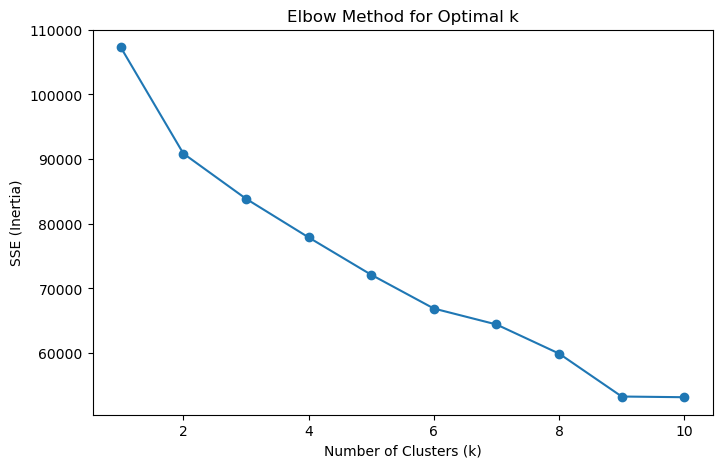

Silhouette Score: 0.1980894178271382
3    2770
1     877
2     807
0     656
dtype: int64


In [2]:
%matplotlib inline

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import pandas as pd

sse = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    sse.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(list(k_values), sse, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("SSE (Inertia)")
plt.title("Elbow Method for Optimal k")
plt.show()

k_optimal = 4
kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

sil_score = silhouette_score(X_scaled, kmeans_labels)
print("Silhouette Score:", sil_score)
print(pd.Series(kmeans_labels).value_counts())

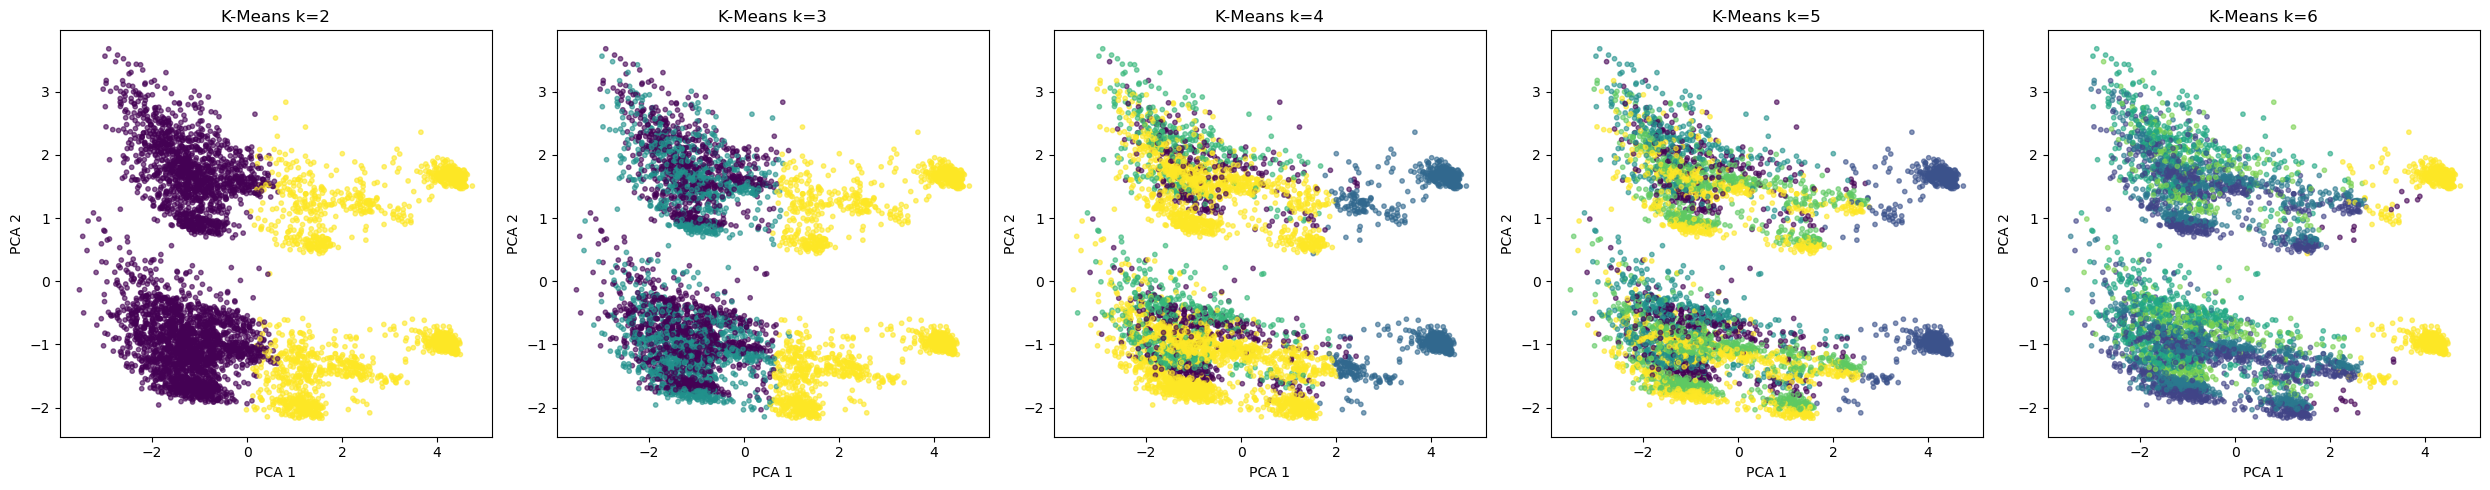

,k,SSE,Silhouette,Cluster Percentages
0,2,90871.686697,0.178888,"{0: 67.3, 1: 32.7}"
1,3,83882.532146,0.144882,"{0: 35.6, 1: 33.99, 2: 30.41}"
2,4,77901.388074,0.198089,"{3: 54.21, 1: 17.16, 2: 15.79, 0: 12.84}"
3,5,72119.806735,0.183374,"{3: 28.63, 4: 28.59, 2: 15.91, 1: 14.01, 0: 12..."
4,6,66898.929695,0.190228,"{2: 28.63, 1: 28.57, 3: 15.91, 5: 13.6, 4: 12...."


In [3]:
from sklearn.decomposition import PCA
import numpy as np

k_list = [2, 3, 4, 5, 6]

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 5, figsize=(25, 5))

kmeans_experiment_results = []

for i, k in enumerate(k_list):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)

    axes[i].scatter(X_pca[:, 0], X_pca[:, 1], c=labels, s=10, alpha=0.6)
    axes[i].set_title(f"K-Means k={k}")
    axes[i].set_xlabel("PCA 1")
    axes[i].set_ylabel("PCA 2")

    cluster_percents = (pd.Series(labels).value_counts(normalize=True) * 100).round(2)

    kmeans_experiment_results.append({
        "k": k,
        "SSE": km.inertia_,
        "Silhouette": silhouette_score(X_scaled, labels),
        "Cluster Percentages": cluster_percents.to_dict()
    })

plt.tight_layout()
plt.show()

kmeans_results_df = pd.DataFrame(kmeans_experiment_results)
kmeans_results_df

In [4]:
from scipy.spatial.distance import cdist
import numpy as np

# Use your best K-Means model: k = 4
kmeans_best = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans_best_labels = kmeans_best.fit_predict(X_scaled)

# f(x) = distance from point x to nearest centroid
kmeans_anomaly_scores = np.min(
    cdist(X_scaled, kmeans_best.cluster_centers_),
    axis=1
)

# Top 3% most distant points are outliers
threshold = np.percentile(kmeans_anomaly_scores, 97)
kmeans_outliers = kmeans_anomaly_scores > threshold

print("Anomaly threshold:", threshold)
print("Number of outliers:", kmeans_outliers.sum())
print("Percent outliers:", round(kmeans_outliers.mean() * 100, 2), "%")

Anomaly threshold: 5.687593169457626
Number of outliers: 154
Percent outliers: 3.01 %


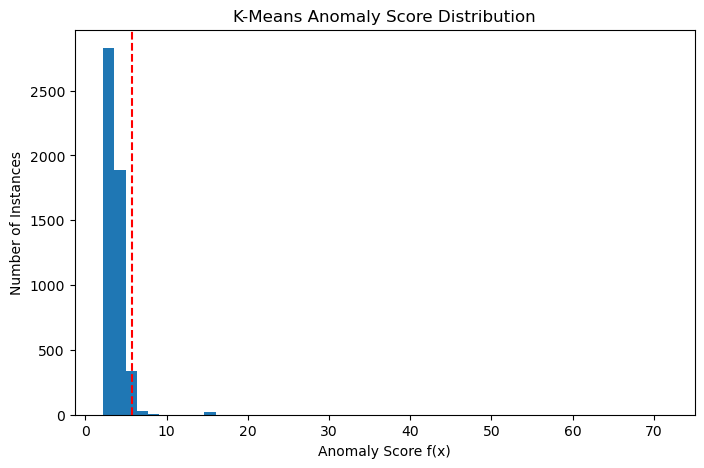

In [5]:
plt.figure(figsize=(8,5))
plt.hist(kmeans_anomaly_scores, bins=50)
plt.axvline(threshold, color="red", linestyle="--")
plt.xlabel("Anomaly Score f(x)")
plt.ylabel("Number of Instances")
plt.title("K-Means Anomaly Score Distribution")
plt.show()

In [6]:
# Compare outliers vs normal points
outlier_analysis = stroke_df.copy()
outlier_analysis["kmeans_outlier"] = kmeans_outliers

outlier_analysis.groupby("kmeans_outlier")[["age", "avg_glucose_level", "bmi"]].mean()

,age,avg_glucose_level,bmi
kmeans_outlier,,,
False,42.712470,104.480864,28.776340
True,59.772727,159.788766,32.655185


In [7]:
from sklearn.cluster import AgglomerativeClustering
import time

link_types = ["single", "complete", "average", "ward"]
k_list = [3, 4]

hier_results = []
hier_labels_dict = {}

for link in link_types:
    for k in k_list:
        start = time.time()
        
        model = AgglomerativeClustering(n_clusters=k, linkage=link)
        labels = model.fit_predict(X_scaled)
        
        end = time.time()
        
        hier_labels_dict[(link, k)] = labels
        
        cluster_percent = (pd.Series(labels).value_counts(normalize=True) * 100).round(2)
        
        hier_results.append({
            "Link": link,
            "k": k,
            "Time": round(end - start, 4),
            "Cluster %": cluster_percent.to_dict()
        })

hier_df = pd.DataFrame(hier_results)
hier_df

,Link,k,Time,Cluster %
0,single,3,3.7368,"{0: 99.55, 2: 0.43, 1: 0.02}"
1,single,4,0.9762,"{0: 99.51, 2: 0.43, 1: 0.04, 3: 0.02}"
2,complete,3,3.4973,"{0: 99.55, 2: 0.43, 1: 0.02}"
3,complete,4,1.9384,"{1: 93.39, 0: 6.16, 2: 0.43, 3: 0.02}"
4,average,3,2.0597,"{0: 99.55, 2: 0.43, 1: 0.02}"
5,average,4,2.3838,"{0: 99.51, 2: 0.43, 1: 0.04, 3: 0.02}"
6,ward,3,2.8581,"{2: 49.61, 0: 36.54, 1: 13.86}"
7,ward,4,3.3021,"{2: 49.61, 1: 25.62, 0: 13.86, 3: 10.92}"


In [8]:

hier_model = AgglomerativeClustering(n_clusters=4, linkage="ward")  # or "average" if you chose that
hier_labels = hier_model.fit_predict(X_scaled)

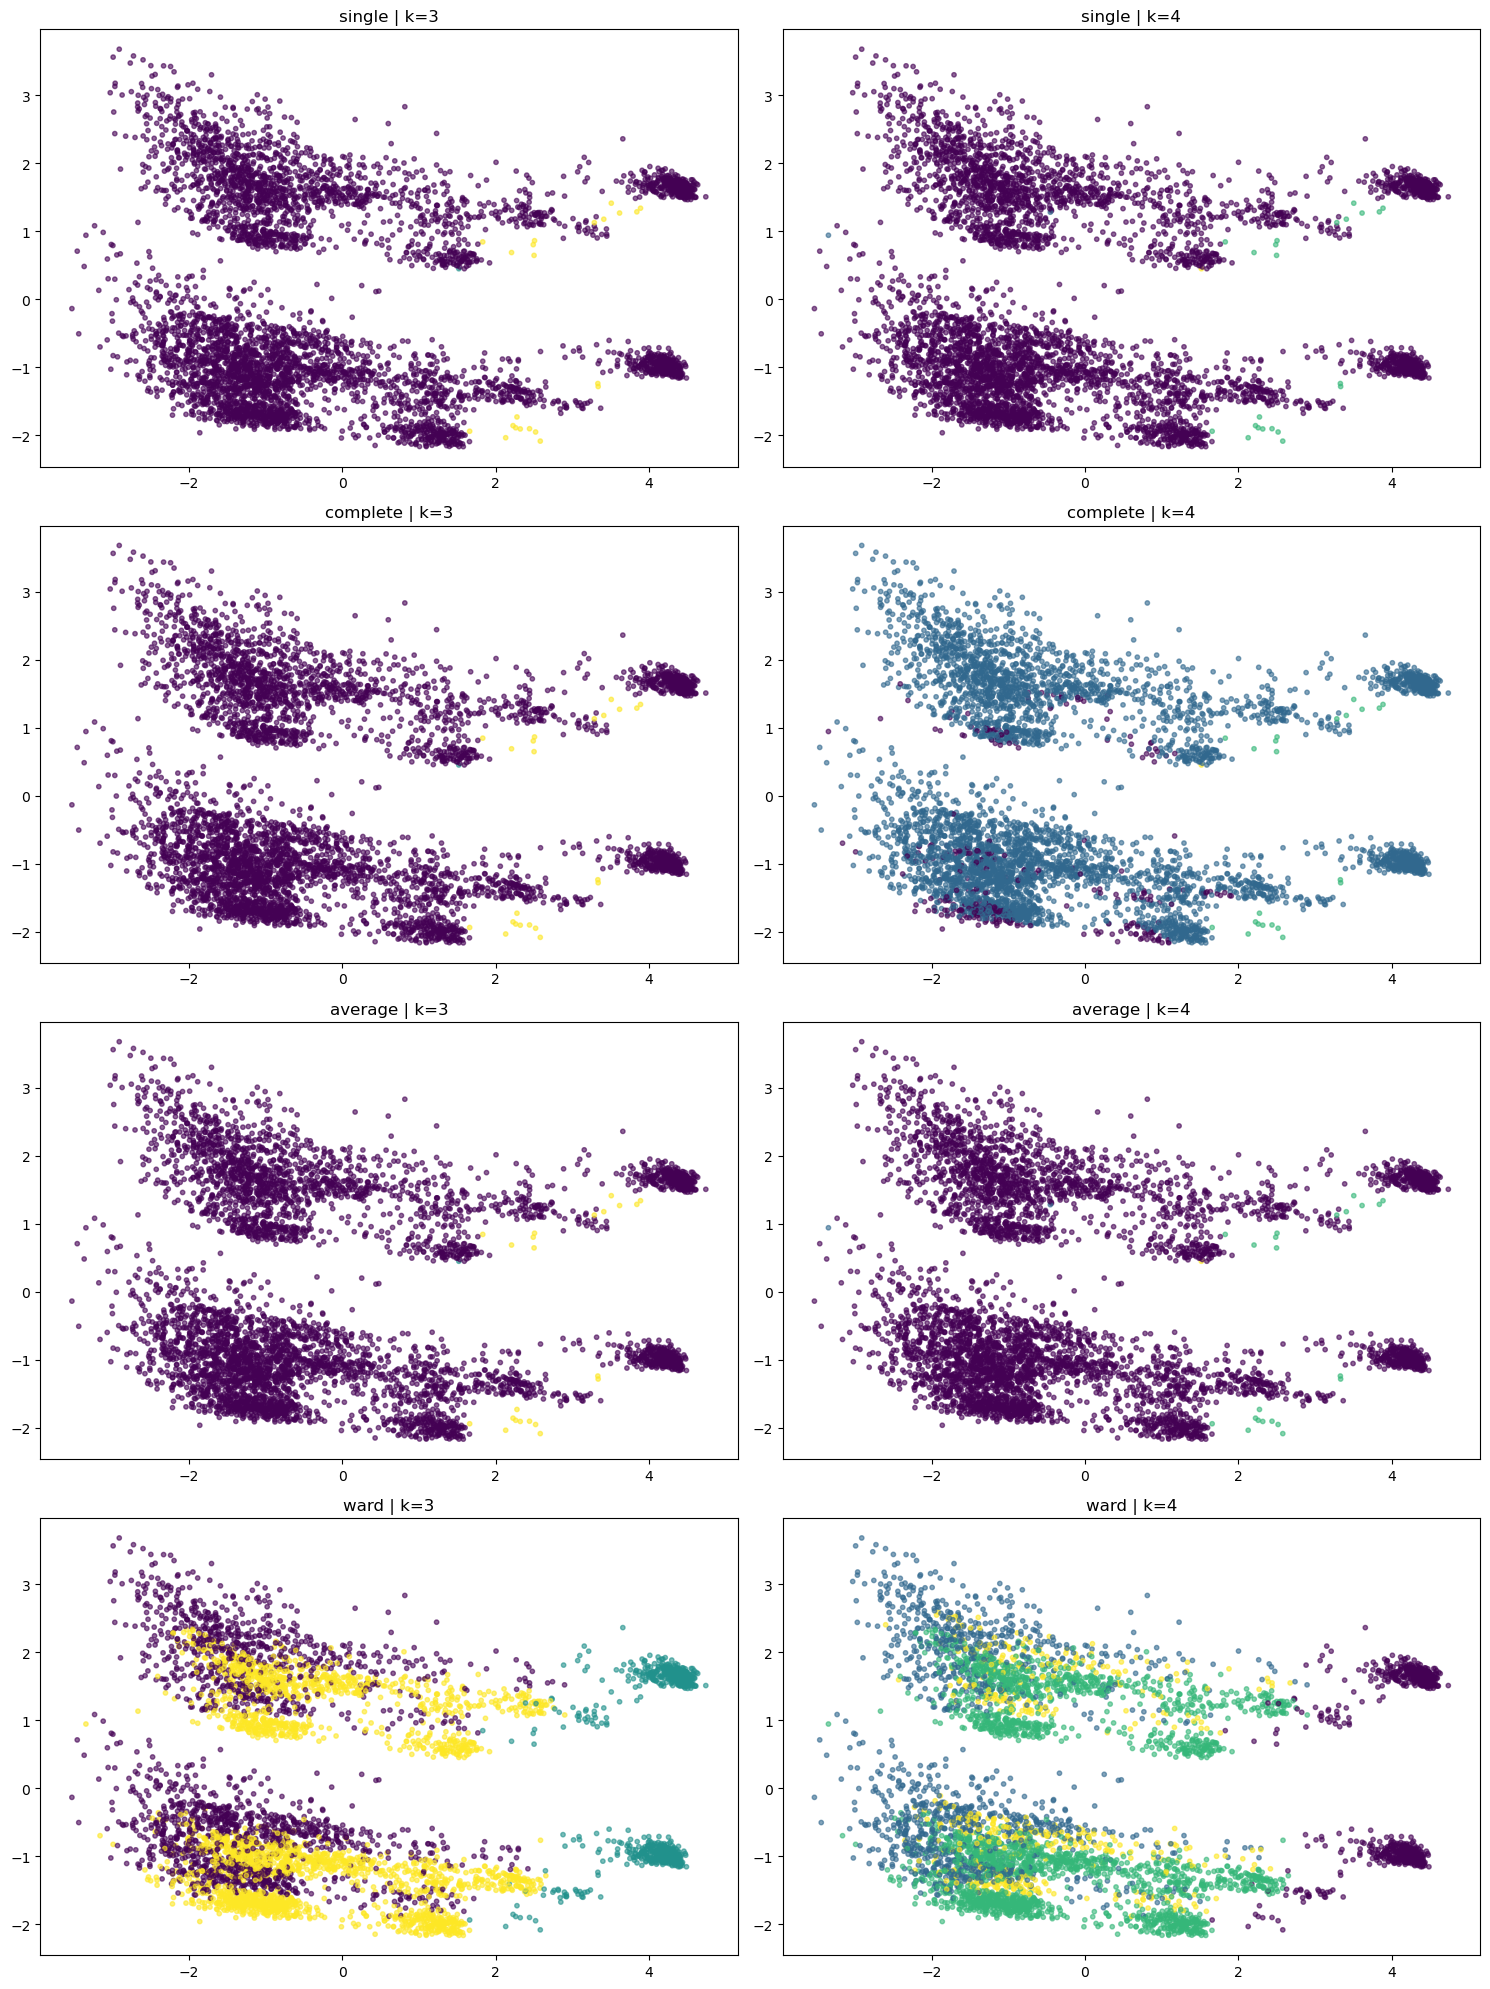

In [9]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(4, 2, figsize=(15, 20))

for i, link in enumerate(link_types):
    for j, k in enumerate(k_list):
        labels = hier_labels_dict[(link, k)]
        
        axes[i, j].scatter(X_pca[:,0], X_pca[:,1], c=labels, s=10, alpha=0.6)
        axes[i, j].set_title(f"{link} | k={k}")

plt.tight_layout()
plt.show()

Outliers: 154


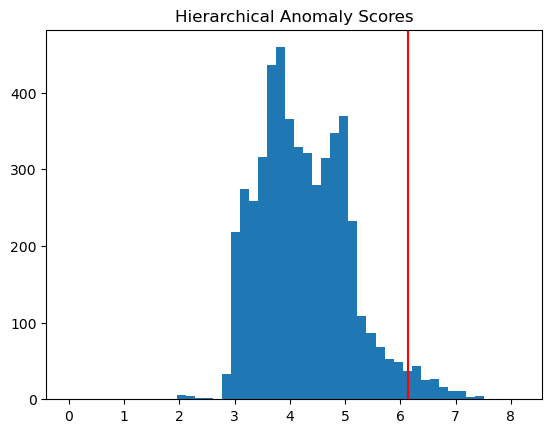

,age,avg_glucose_level,bmi
hier_outlier,,,
False,42.471348,104.407452,28.743611
True,67.532468,162.151299,33.708476


In [10]:
import numpy as np


labels = hier_labels_dict[("average", 4)]

centroids = np.array([
    X_scaled[labels == i].mean(axis=0) for i in np.unique(labels)
])

distances = np.array([
    np.linalg.norm(X_scaled[i] - centroids[labels[i]])
    for i in range(len(X_scaled))
])

threshold = np.percentile(distances, 97)
outliers = distances > threshold

print("Outliers:", outliers.sum())

plt.hist(distances, bins=50)
plt.axvline(threshold, color='red')
plt.title("Hierarchical Anomaly Scores")
plt.show()

outlier_analysis = stroke_df.copy()
outlier_analysis["hier_outlier"] = outliers

outlier_analysis.groupby("hier_outlier")[["age","avg_glucose_level","bmi"]].mean()

In [11]:
from sklearn.cluster import DBSCAN
import time

eps_values = [0.3, 0.5, 0.7, 1.0, 1.5]   # 5 experiments
min_samples = 5

dbscan_results = []

for eps in eps_values:
    start = time.time()
    
    db = DBSCAN(eps=eps, min_samples=min_samples)
    labels = db.fit_predict(X_scaled)
    
    end = time.time()
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    cluster_percent = (pd.Series(labels).value_counts(normalize=True) * 100).round(2)
    noise_percent = (labels == -1).sum() / len(labels) * 100
    
    dbscan_results.append({
        "eps": eps,
        "minPts": min_samples,
        "Clusters": n_clusters,
        "Noise %": round(noise_percent, 2),
        "Cluster %": cluster_percent.to_dict(),
        "Time": round(end - start, 4)
    })

dbscan_df = pd.DataFrame(dbscan_results)
dbscan_df



,eps,minPts,Clusters,Noise %,Cluster %,Time
0,0.3,5,63,81.70,"{-1: 81.7, 7: 2.64, 8: 2.31, 4: 2.29, 6: 2.05,...",0.2079
1,0.5,5,74,52.29,"{-1: 52.29, 4: 3.31, 9: 3.23, 26: 3.23, 21: 2....",0.2038
2,0.7,5,96,34.29,"{-1: 34.29, 7: 4.03, 13: 3.58, 35: 3.35, 30: 2...",0.1989
3,1.0,5,114,20.96,"{-1: 20.96, 10: 4.6, 19: 4.27, 57: 3.35, 49: 2...",0.1968
4,1.5,5,122,12.62,"{-1: 12.62, 19: 4.64, 28: 4.31, 68: 3.35, 61: ...",0.1676


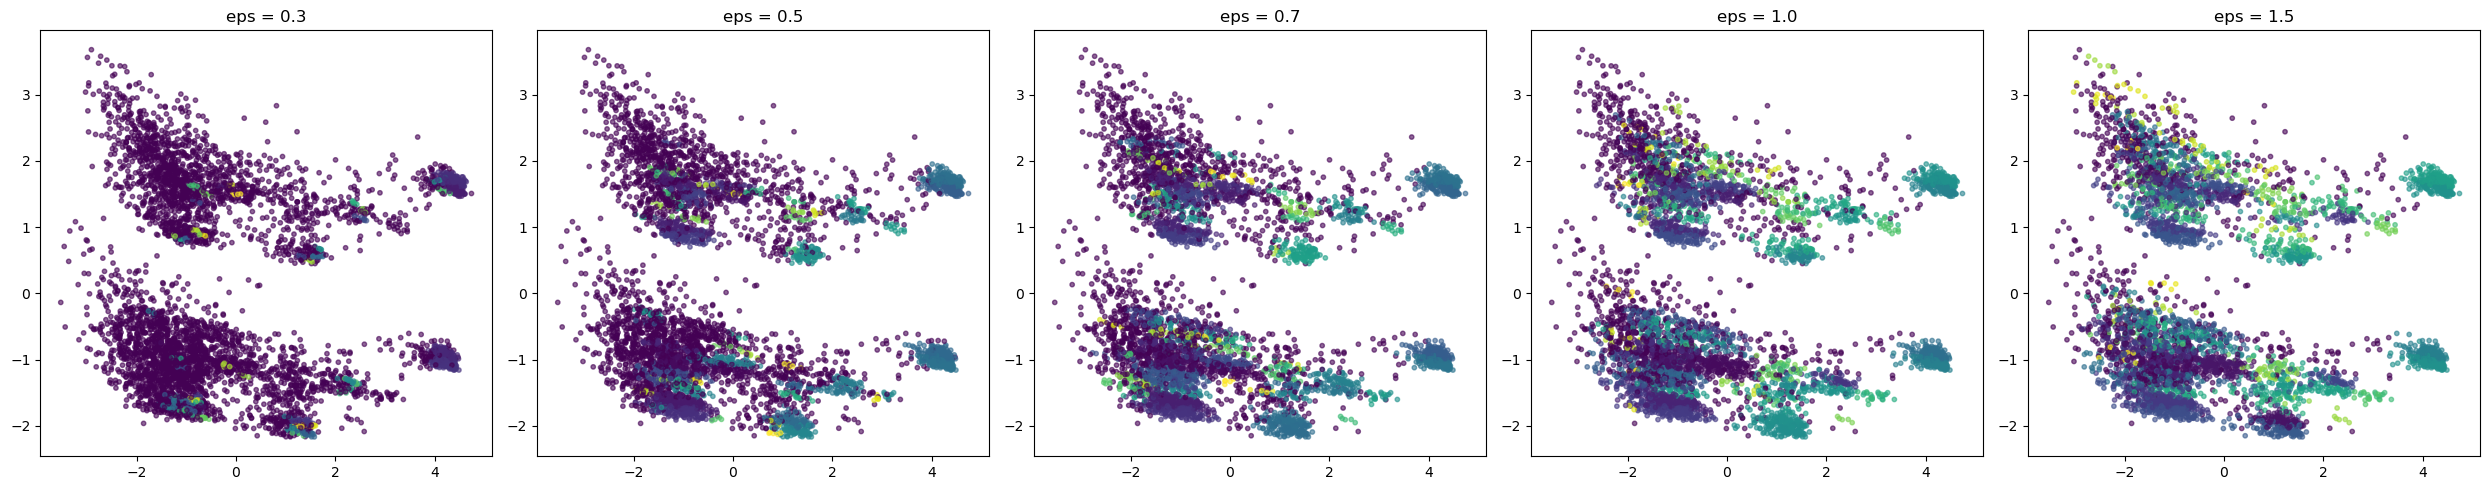

In [12]:
fig, axes = plt.subplots(1, 5, figsize=(25,5))

for i, eps in enumerate(eps_values):
    db = DBSCAN(eps=eps, min_samples=5)
    labels = db.fit_predict(X_scaled)
    
    axes[i].scatter(X_pca[:,0], X_pca[:,1], c=labels, s=10, alpha=0.6)
    axes[i].set_title(f"eps = {eps}")

plt.tight_layout()
plt.show()

In [13]:
outliers = (labels == -1)
outlier_analysis = stroke_df.copy()
outlier_analysis["dbscan_outlier"] = outliers

outlier_analysis.groupby("dbscan_outlier")[["age","avg_glucose_level","bmi"]].mean()

,age,avg_glucose_level,bmi
dbscan_outlier,,,
False,41.471445,101.354262,28.260355
True,55.376744,139.330000,33.274349


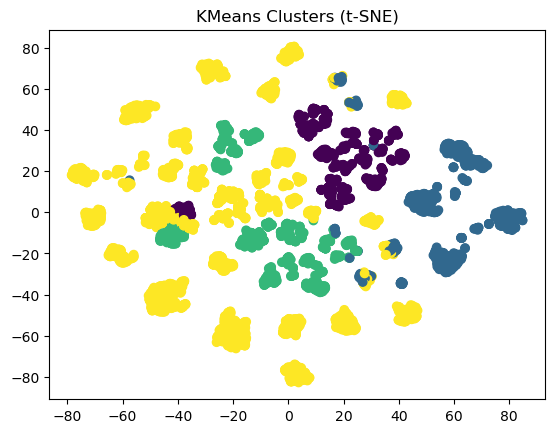

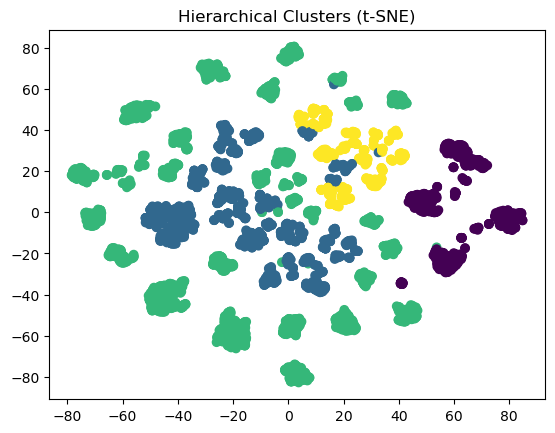

In [14]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

plt.figure()
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=kmeans_labels)
plt.title("KMeans Clusters (t-SNE)")
plt.show()

plt.figure()
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=hier_labels)
plt.title("Hierarchical Clusters (t-SNE)")
plt.show()

In [15]:
from sklearn.metrics import pairwise_distances
import seaborn as sns
import numpy as np


dist_matrix = pairwise_distances(X_scaled)


incidence_matrix = (kmeans_labels[:, None] == kmeans_labels).astype(int)


correlation = np.corrcoef(dist_matrix.flatten(), incidence_matrix.flatten())[0,1]

print("Correlation between distance and cluster membership:", correlation)

Correlation between distance and cluster membership: -0.3504766252229942


In [16]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, adjusted_mutual_info_score

ari = adjusted_rand_score(kmeans_labels, hier_labels)
nmi = normalized_mutual_info_score(kmeans_labels, hier_labels)
ami = adjusted_mutual_info_score(kmeans_labels, hier_labels)

print("ARI:", ari)
print("NMI:", nmi)
print("AMI:", ami)

ARI: 0.6742210578718596
NMI: 0.6982368352667011
AMI: 0.6980150244873515


In [17]:
from sklearn.metrics import homogeneity_score, completeness_score, v_measure_score

y = stroke_df["stroke"]

print("Homogeneity:", homogeneity_score(y, kmeans_labels))
print("Completeness:", completeness_score(y, kmeans_labels))
print("V-measure:", v_measure_score(y, kmeans_labels))

Homogeneity: 0.04398491970794789
Completeness: 0.007201979163146428
V-measure: 0.01237732631652733


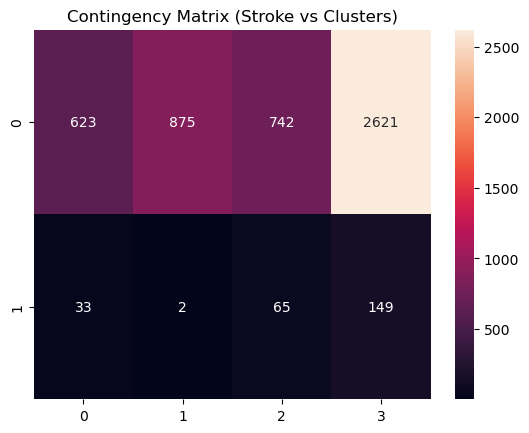

In [18]:
from sklearn.metrics.cluster import contingency_matrix

cm = contingency_matrix(y, kmeans_labels)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Contingency Matrix (Stroke vs Clusters)")
plt.show()

In [19]:
from sklearn.metrics import homogeneity_score, completeness_score, v_measure_score

print("Homogeneity:", homogeneity_score(y, hier_labels))
print("Completeness:", completeness_score(y, hier_labels))
print("V-measure:", v_measure_score(y, hier_labels))

Homogeneity: 0.06457680445386446
Completeness: 0.010373946393301808
V-measure: 0.01787617335605255


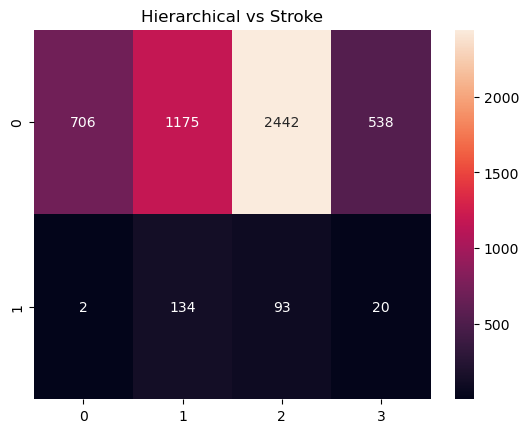

In [20]:
from sklearn.metrics.cluster import contingency_matrix

cm = contingency_matrix(y, hier_labels)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Hierarchical vs Stroke")
plt.show()